In [1]:
import os
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset
import matplotlib.pyplot as plt
from collections import defaultdict
from datasets import load_dataset
from transformers import AutoModelForCausalLM, GPT2Config, TrainingArguments, Trainer
from sentencepiece import SentencePieceTrainer, SentencePieceProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {device}")

PyTorch device: cuda


# Stage 1

## Load Dataset

In [2]:
# This does not work: "RuntimeError: Dataset scripts are no longer supported, but found ptb_text_only.py"
#dataset = load_dataset("ptb_text_only")

data_files = {
    "train": "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.train.txt",
    "test": "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.test.txt",
    "valid": "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.valid.txt",
}
dataset = load_dataset("text", data_files=data_files)
del data_files

## Preprocess and Tokenize

In [3]:
# Join all rows in all splits by newlines
joined_text = "\n".join([row["text"] for split in dataset.values() for row in split])
print(f"Total characters: {len(joined_text)}")

if not os.path.isfile("corpus.txt"):
    with open("corpus.txt", "w") as f:
        f.write(joined_text)

# Train tokenizer if it is not there
if not os.path.isfile("tokenizer.model"):
    SentencePieceTrainer.train(
        input="corpus.txt",
        model_prefix="tokenizer",
        vocab_size=8000,
        character_coverage=1.0,
        pad_id=0,
        pad_piece="<pad>",
        unk_id=1,
        unk_piece="<unk>",
        bos_id=2,
        bos_piece="<bos>",
        eos_id=3,
        eos_piece="<eos>"
    )

# Load and use tokenizer
tokenizer = SentencePieceProcessor()
tokenizer.load("tokenizer.model")

joined_tokens = tokenizer.encode(joined_text)
print(f"Total tokens: {len(joined_tokens)}")

del joined_tokens, joined_text

tokenized_dataset = {
    split: tokenizer.encode("\n".join([row["text"] for row in dataset[split]]))
    for split in ["train", "test", "valid"]
}

Total characters: 5951344
Total tokens: 1456887


## Initialize Model

In [4]:
config = GPT2Config(
    vocab_size=tokenizer.vocab_size(),
    n_positions=128,
    n_ctx=128,
    n_embd=256,
    n_layer=4,
    n_head=4,
    n_inner=1024,
    embd_pdrop=0.1,
    attn_pdrop=0.1,
    resid_pdrop=0.1,
    tie_word_embeddings=True,
    bos_token_id=tokenizer.bos_id(),
    eos_token_id=tokenizer.eos_id(),
    pad_token_id=tokenizer.pad_id(),
    unk_token_id=tokenizer.unk_id(),
)
model = AutoModelForCausalLM.from_config(config)
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(8000, 256)
    (wpe): Embedding(128, 256)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPT2Block(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=768, nx=256)
          (c_proj): Conv1D(nf=256, nx=256)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=1024, nx=256)
          (c_proj): Conv1D(nf=256, nx=1024)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=256, out_features=8000, bias=False)
)

## Train

In [5]:
block_size = 128

class RandomBlocksDataset(TorchDataset):
    def __init__(self, tokens):
        self.tokens = tokens
        self.block_size = block_size
    def __len__(self):
        return len(self.tokens) // self.block_size
    def __getitem__(self, i):
        start = random.randint(0, len(self.tokens) - self.block_size - 1)
        x = torch.tensor(self.tokens[start:start + self.block_size], dtype=torch.long)
        return {
            "input_ids": x,
            "labels": x.clone(),
            "attention_mask": torch.ones_like(x, dtype=torch.long)
        }


args = TrainingArguments(
    output_dir="pretraining",
    max_steps=3000,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    eval_strategy="steps",
    eval_steps=200,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=RandomBlocksDataset(tokenized_dataset["train"]),
    eval_dataset=RandomBlocksDataset(tokenized_dataset["test"])
)

print("Training...")
model.config.use_cache = False
train_results = trainer.train()
logs = trainer.state.log_history
model.config.use_cache = True
trainer.save_model("pretrained")

print("Evaluating...")
train_metrics = trainer.evaluate()


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training...


Step,Training Loss,Validation Loss
200,5.848800,5.425658
400,5.042300,4.725213
600,4.779800,4.503263
800,4.678400,4.460317
1000,4.538000,4.312519
1200,4.525800,4.256703
1400,4.436100,4.231542
1600,4.413900,4.230777
1800,4.390200,4.154831
2000,4.349300,4.132804


Evaluating...


Training loss: 4.655223800659179
Validation loss: 4.0652666091918945
Validation perplexity: 58.28044455366131


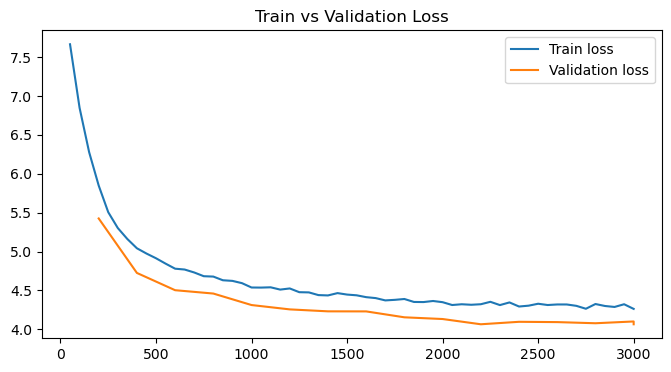

In [10]:
print(f"Training loss: {train_results.training_loss}")
print(f"Validation loss: {train_metrics["eval_loss"]}")
print(f"Validation perplexity: {math.exp(train_metrics["eval_loss"])}")

train_steps = [x["step"] for x in logs if "loss" in x and "learning_rate" in x]
train_loss  = [x["loss"] for x in logs if "loss" in x and "learning_rate" in x]
eval_steps  = [x["step"] for x in logs if "eval_loss" in x]
eval_loss   = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(train_steps, train_loss, label="Train loss")
plt.plot(eval_steps, eval_loss, label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# Stage 2